<a href="https://colab.research.google.com/github/kjian254416-blip/ML300/blob/main/Chapter_02_%EC%9A%B0%EB%A6%AC_%EC%95%A0%EB%8A%94_%EB%A8%B8%EB%A6%AC%EB%8A%94_%EC%A2%8B%EC%9D%80%EB%8D%B0%2C_%EA%B3%B5%EB%B6%80%EB%A5%BC_%EC%95%88%ED%95%B4%EC%84%9C_%EA%B7%B8%EB%9E%98%EC%9A%94(%EB%AC%B8%EC%A0%9C).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 주제 : <br>우리 애는 머리는 좋은데, 공부를 안해서 그래요 - 데이터로 살펴보는 우리 아이 학습 성공/실패 요소
----------

## 실습 가이드
    1. 데이터를 다운로드하여 Colab에 불러옵니다.
    2. 필요한 라이브러리는 모두 코드로 작성되어 있습니다.
    3. 코드는 위에서부터 아래로 순서대로 실행합니다.
    
    
## 데이터 소개
    - 이번 주제는 xAPI-Edu-Data 데이터셋을 사용합니다.
    
    - 다음 1개의 csv 파일을 사용합니다.
    xAPI-Edu-Data.csv
    
    - 각 파일의 컬럼은 아래와 같습니다.
    gender: 학생의 성별 (M: 남성, F: 여성)
    NationaliTy: 학생의 국적
    PlaceofBirth: 학생이 태어난 국가
    StageID: 학생이 다니는 학교 (초,중,고)
    GradeID: 학생이 속한 성적 등급
    SectionID: 학생이 속한 반 이름
    Topic: 수강한 과목
    Semester: 수강한 학기 (1학기/2학기)
    Relation: 주 보호자와 학생의 관계
    raisedhands: 학생이 수업 중 손을 든 횟수
    VisITedResources: 학생이 과목 공지를 확인한 횟수
    Discussion: 학생이 토론 그룹에 참여한 횟수
    ParentAnsweringSurvey: 부모가 학교 설문에 참여했는지 여부
    ParentschoolSatisfaction: 부모가 학교에 만족했는지 여부
    StudentAbscenceDays: 학생의 결석 횟수 (7회 이상/미만)
    Class: 학생의 성적 등급 (L: 낮음, M: 보통, H: 높음)
        
    
    
- 데이터 출처: https://www.kaggle.com/aljarah/xAPI-Edu-Data

## 최종 목표
    - 연구용 Tabular 데이터의 이해
    - 데이터 시각화를 통한 인사이트 습득 방법의 이해
    - Scikit-learn 기반의 모델 학습 방법 습득
    - Logistic Regression, XGBoost 기반의 모델 학습 방법 습득
    - 학습된 모델의 평가 방법 및 시각화 방법 습득

- 출제자 : 신제용 강사
---

## Step 0. 의료 데이터셋에 대하여

### 연구용 데이터의 목적


### 연구용 데이터의 인용


## Step 1. 데이터셋 준비하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 문제 1. Colab Notebook에 Kaggle API 세팅하기


In [2]:
import os

In [3]:
# os.environ을 이용하여 Kaggle API Username, Key 세팅하기

os.environ['KAGGLE_USERNAME'] = 'kimjian254416'
os.environ['KAGGLE_KEY'] = '0457ef800614319f99e6b8144bfd741e'

### 문제 2. 데이터 다운로드 및 압축 해제하기


### 문제 3. Pandas 라이브러리로 csv파일 읽어들이기


In [9]:
#Linux 명령어로 Kaggle API를 이용하여 데이터셋 다운로드하기(!kaggle)
#Linux 명령어로 압축해제하기
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "xAPI-Edu-Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aljarah/xAPI-Edu-Data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_211/476211522.py:12: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'xapi-edu-data' dataset.
First 5 records:   gender NationalITy PlaceofBirth     StageID GradeID SectionID Topic  \
0      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
1      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
2      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
3      M          KW       KuwaIT  lowerlevel    G-04         A    IT   
4      M          KW       KuwaIT  lowerlevel    G-04         A    IT   

  Semester Relation  raisedhands  VisITedResources  AnnouncementsView  \
0        F   Father           15                16                  2   
1        F   Father           20                20                  3   
2        F   Father           10                 7                  0   
3        F   Father           30                25                  5   
4        F   Father           40                50                 12   

   Discussion ParentAnsweringSurvey P

In [13]:
# pd.read_csv()로 csv파일 읽어들이기


## Step 2. EDA 및 데이터 기초 통계 분석


### 문제 4. 데이터프레임의 각 컬럼 분석하기


In [54]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,Class_value
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,0
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,0
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,-1
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,-1
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [17]:
df.describe()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
count,480.000000,480.000000,480.000000,480.000000
mean,46.775000,54.797917,37.918750,43.283333
std,30.779223,33.080007,26.611244,27.637735
min,0.000000,0.000000,0.000000,1.000000
25%,15.750000,20.000000,14.000000,20.000000
50%,50.000000,65.000000,33.000000,39.000000
75%,75.000000,84.000000,58.000000,70.000000
max,100.000000,99.000000,98.000000,99.000000


In [21]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [22]:
df['gender'].value_counts()

,count
gender,
M,305
F,175


In [23]:
df['NationalITy'].value_counts()

,count
NationalITy,
KW,179
Jordan,172
Palestine,28
Iraq,22
lebanon,17
Tunis,12
SaudiArabia,11
Egypt,9
Syria,7


In [24]:
df['PlaceofBirth'].value_counts()

,count
PlaceofBirth,
KuwaIT,180
Jordan,176
Iraq,22
lebanon,19
USA,16
SaudiArabia,16
Palestine,10
Egypt,9
Tunis,9


### 문제 5. 수치형 데이터의 히스토그램 그리기


In [25]:
# seaborn의 histplot, jointplot, pairplot을 이용해 히스토그램 그리기

df.columns



Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

<Axes: xlabel='raisedhands', ylabel='Count'>

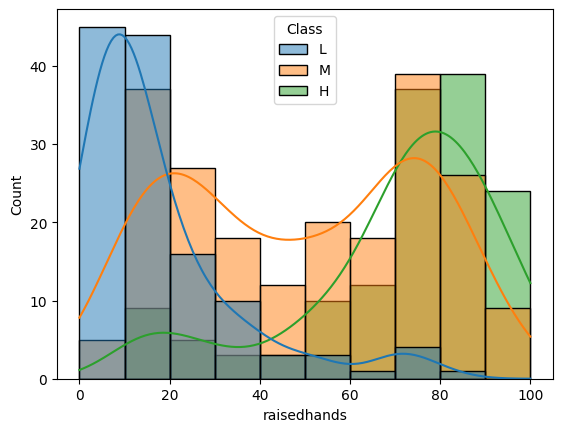

In [31]:
sns.histplot(x='raisedhands',data = df,hue = 'Class',hue_order =['L','M','H'], kde = True)

<Axes: xlabel='VisITedResources', ylabel='Count'>

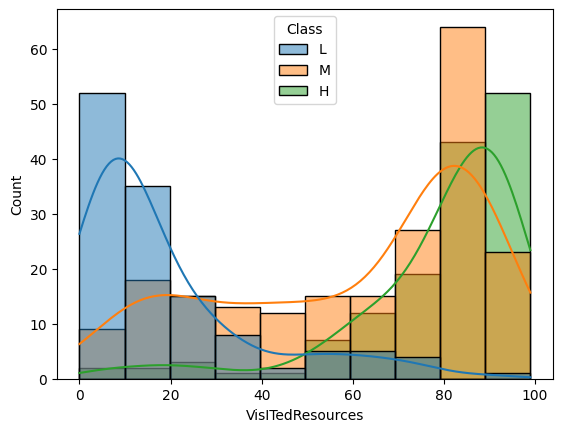

In [32]:
sns.histplot(x='VisITedResources',data = df,hue = 'Class',hue_order =['L','M','H'], kde = True)

<Axes: xlabel='AnnouncementsView', ylabel='Count'>

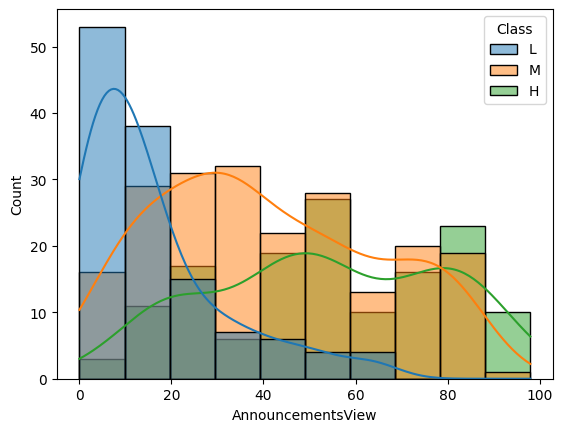

In [33]:
sns.histplot(x='AnnouncementsView',data = df,hue = 'Class',hue_order =['L','M','H'], kde = True)

<Axes: xlabel='Discussion', ylabel='Count'>

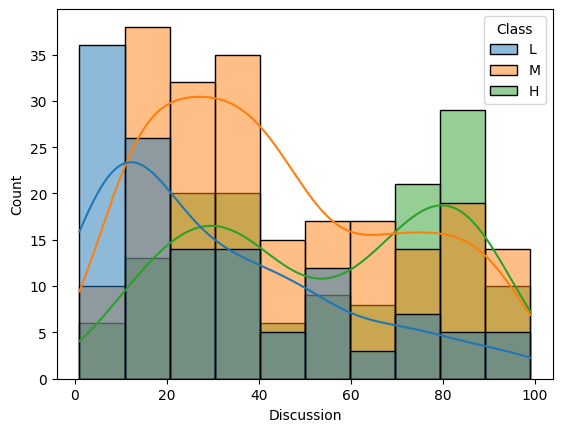

In [34]:
sns.histplot(x='Discussion',data = df,hue = 'Class',hue_order =['L','M','H'], kde = True)

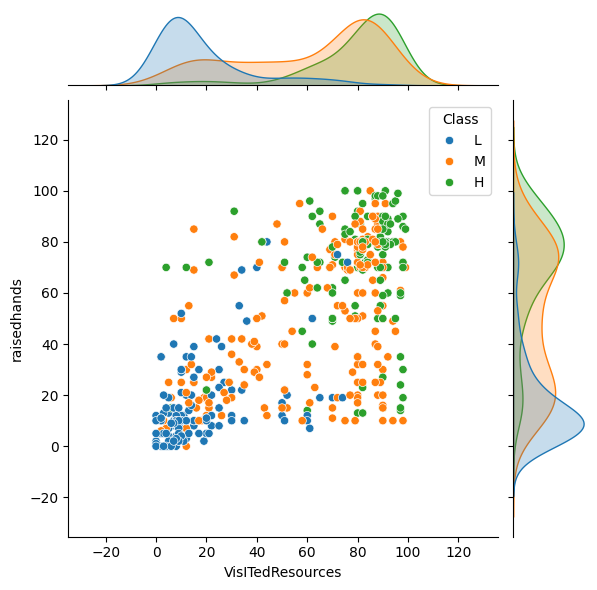

In [36]:
sns.jointplot(x='VisITedResources',y = 'raisedhands',data = df,hue = 'Class',hue_order=['L','M','H'])

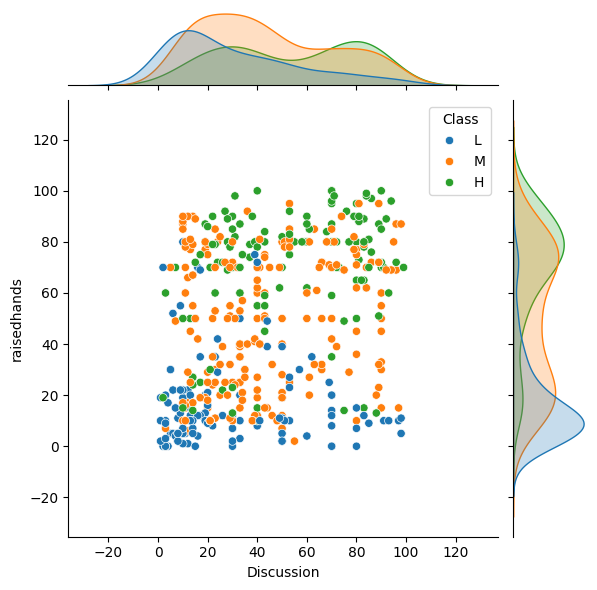

In [38]:
sns.jointplot(x='Discussion',y = 'raisedhands',data = df,hue ='Class', hue_order = ['L','M','H'])

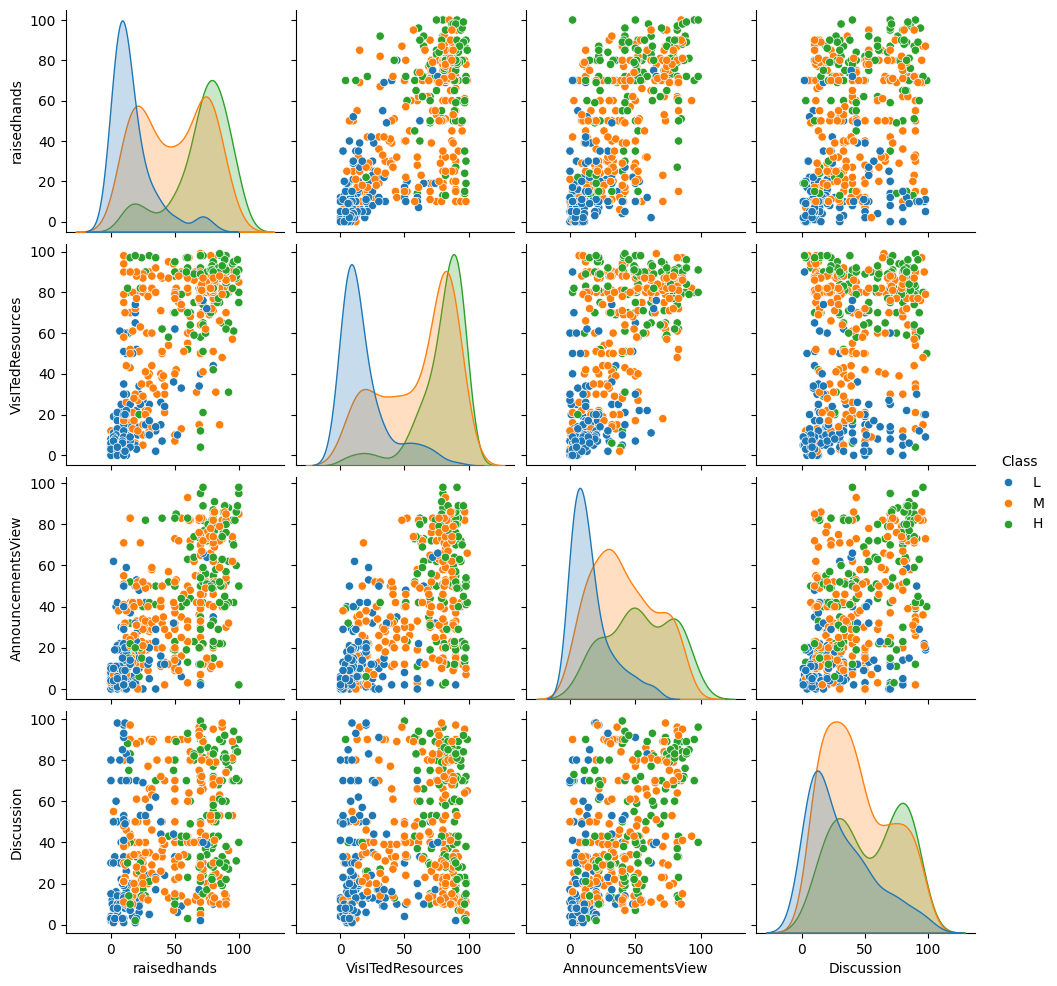

In [40]:
sns.pairplot(df,hue = 'Class',hue_order =['L','M','H'])

### 문제 6. Countplot을 이용하여 범주별 통계 확인하기


<Axes: xlabel='Class', ylabel='count'>

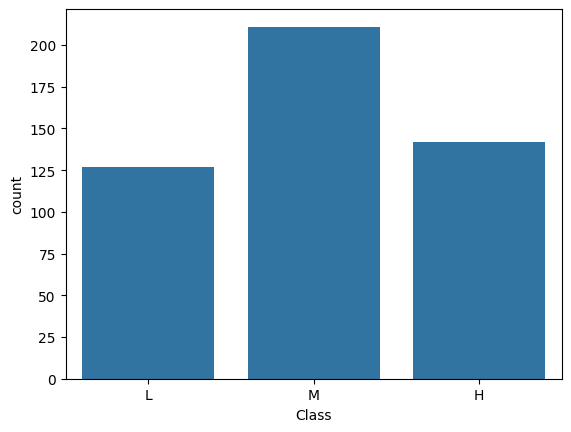

In [41]:
# seaborn의 countplot()을 사용
# Hint) x와 hue를 사용하여 범주별 Class 통계 확인

sns.countplot(x='Class',data = df ,order =['L','M','H'])



<Axes: xlabel='gender', ylabel='count'>

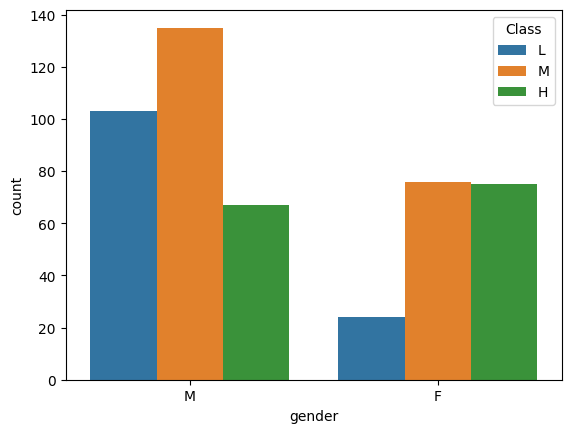

In [42]:
sns.countplot(x = 'gender',data = df , hue = 'Class',hue_order = ['L','M','H'])

In [43]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

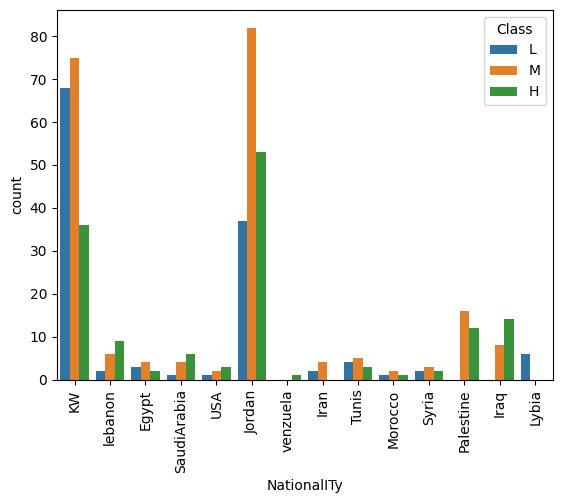

In [45]:
sns.countplot(x = 'NationalITy',data = df , hue = 'Class',hue_order = ['L','M','H'])
plt.xticks(rotation = 90)
plt.show()

<Axes: xlabel='ParentAnsweringSurvey', ylabel='count'>

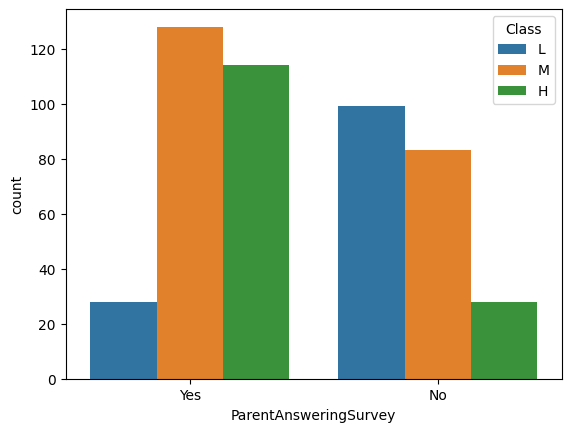

In [47]:
sns.countplot(x = 'ParentAnsweringSurvey',data = df , hue = 'Class',hue_order = ['L','M','H'])

<Axes: xlabel='ParentschoolSatisfaction', ylabel='count'>

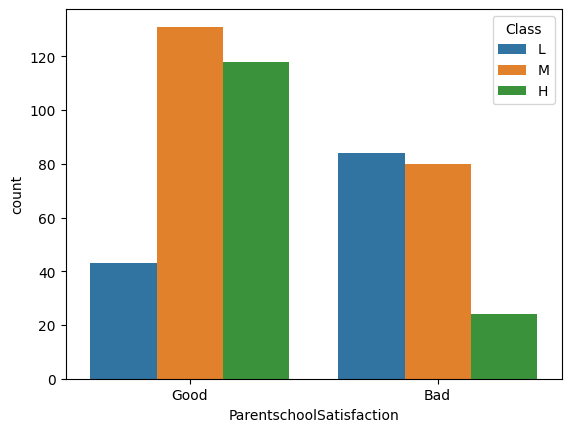

In [48]:
sns.countplot(x = 'ParentschoolSatisfaction',data = df , hue = 'Class',hue_order = ['L','M','H'])

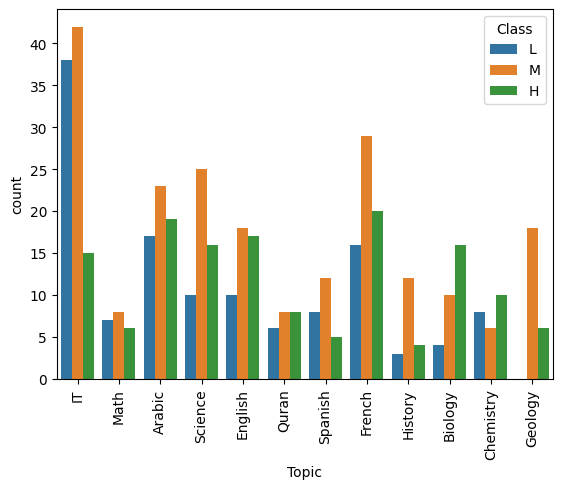

In [49]:
sns.countplot(x = 'Topic',data = df , hue = 'Class',hue_order = ['L','M','H'])
plt.xticks(rotation = 90)
plt.show()

### 문제 7. 범주형 대상 Class 컬럼을 수치로 바꾸어 표현하기

In [110]:
# L, M, H를 숫자로 바꾸어 표현하기 (eg. L: -1, M: 0, H:1)
# Hint) DataFrame의 map() 메소드를 사용

df['Class_value'] = df['Class'].map(dict(L=0,M=1,H=2))

df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class,Class_value
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M,1
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M,1
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L,0
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L,0
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M,1


<BarContainer object of 2 artists>

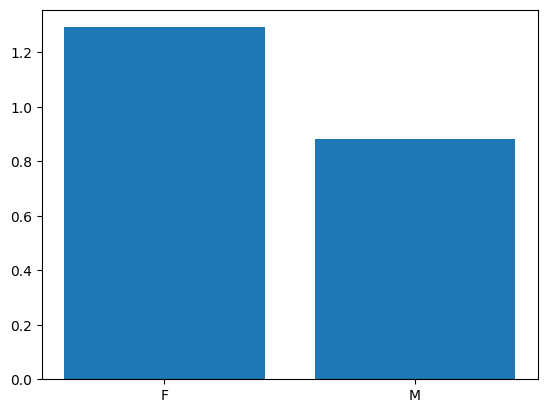

In [111]:
# 숫자로 바꾼 Class_value 컬럼을 이용해 다양한 시각화 수행하기

gb = df.groupby('gender')['Class_value'].mean()
plt.bar(gb.index,gb)

<BarContainer object of 12 artists>

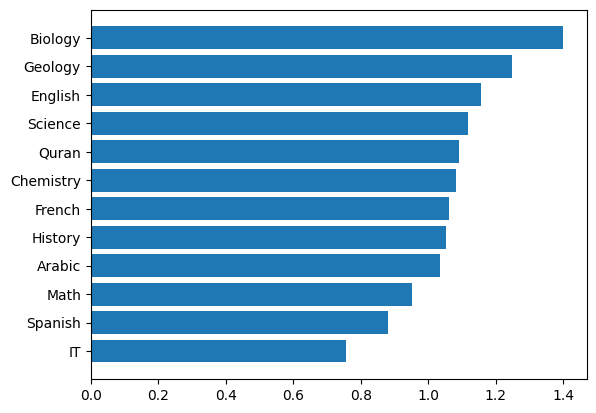

In [112]:
gb = df.groupby('Topic')['Class_value'].mean().sort_values()
plt.barh(gb.index,gb)

<BarContainer object of 2 artists>

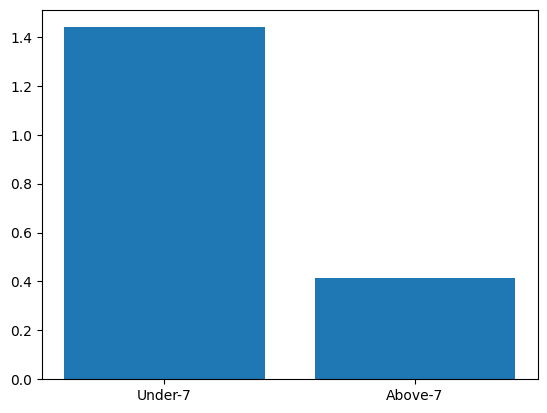

In [113]:
gb = df.groupby('StudentAbsenceDays')['Class_value'].mean().sort_values(ascending = False)
plt.bar(gb.index,gb)

## Step 3. 모델 학습을 위한 데이터 전처리


### 문제 8. get_dummies()를 이용하여 범주형 데이터 전처리하기


In [114]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class', 'Class_value'],
      dtype='object')

In [115]:
# pd.get_dummies()를 이용해 범주형 데이터를 one-hot 벡터로 변환하기
# Hint) Multicollinearity를 피하기 위해 drop_first=True로 설정

x = pd.get_dummies(df.drop(['ParentschoolSatisfaction','Class','Class_value'],axis = 1),columns=['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation',
       'ParentAnsweringSurvey',
       'StudentAbsenceDays'],drop_first=True)
# y를 'Class_value' 컬럼으로 변경하여 XGBoost가 인식할 수 있는 숫자형 타겟 변수로 설정
y = df['Class_value']

In [116]:
x

,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_M,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,...,Topic_History,Topic_IT,Topic_Math,Topic_Quran,Topic_Science,Topic_Spanish,Semester_S,Relation_Mum,ParentAnsweringSurvey_Yes,StudentAbsenceDays_Under-7
0,15,16,2,20,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,True
1,20,20,3,25,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,True,True
2,10,7,0,30,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
3,30,25,5,35,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
4,40,50,12,50,True,False,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,5,4,5,8,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
476,50,77,14,28,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
477,55,74,25,29,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
478,30,17,14,57,False,False,False,True,False,False,...,True,False,False,False,False,False,False,False,False,False


### 문제 9. 학습데이터와 테스트데이터 분리하기


In [117]:
from sklearn.model_selection import train_test_split

In [118]:
# train_test_split() 함수로 학습 데이터와 테스트 데이터 분리하기
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size =  0.3,random_state=1)

## Step 4. Classification 모델 학습하기


### 문제 10. Logistic Regression 모델 생성/학습하기


In [119]:
from sklearn.linear_model import LogisticRegression

In [120]:
# LogisticRegression 모델 생성/학습
model_lr = LogisticRegression(max_iter = 1000)

model_lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

### 문제 11. 모델 학습 결과 평가하기


In [121]:
from sklearn.metrics import classification_report

In [122]:
# Predict를 수행하고 classification_report() 결과 출력하기
pred = model_lr.predict(X_test)
print(classification_report(y_test,pred))


              precision    recall  f1-score   support

           0       0.78      0.76      0.77        33
           1       0.59      0.68      0.63        56
           2       0.77      0.67      0.72        55

    accuracy                           0.69       144
   macro avg       0.72      0.70      0.71       144
weighted avg       0.70      0.69      0.70       144



### 문제 12. XGBoost 모델 생성/학습하기


In [123]:
from xgboost import XGBClassifier

In [124]:
# XGBClassifier 모델 생성/학습
model_xgb = XGBClassifier()
model_xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

### 문제 13. 모델 학습 결과 평가하기


In [125]:
# Predict를 수행하고 classification_report() 결과 출력하기
pred = model_xgb.predict(X_test)
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.84        33
           1       0.67      0.73      0.70        56
           2       0.80      0.71      0.75        55

    accuracy                           0.75       144
   macro avg       0.76      0.76      0.76       144
weighted avg       0.75      0.75      0.75       144



## Step5 모델 학습 결과 심화 분석하기


### 문제 14. Logistic Regression 모델 계수로 상관성 파악하기

In [127]:
model_lr.classes_

array([0, 1, 2])

In [126]:
model_lr.coef_.shape

(3, 59)

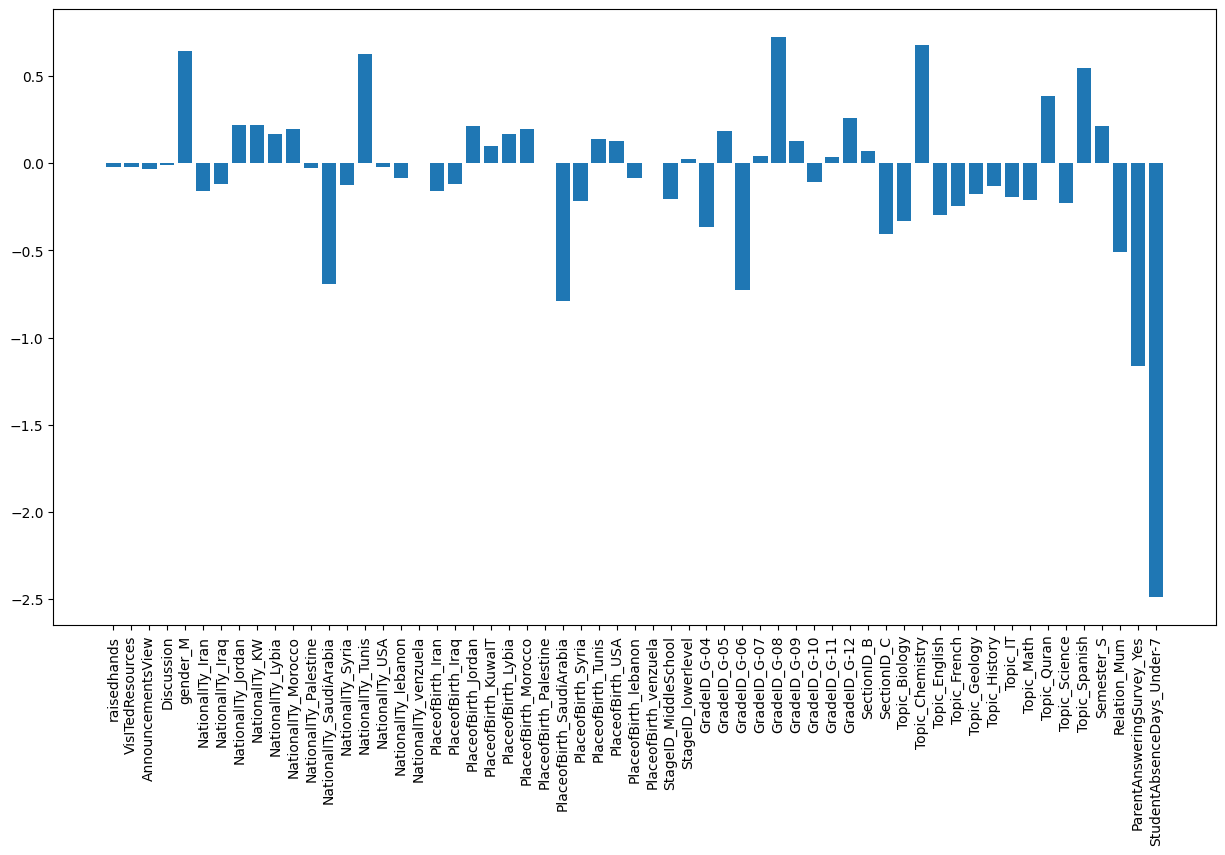

In [130]:
# Logistic Regression 모델의 coef_ 속성을 plot하기
fig = plt.figure(figsize=(15,8))
plt.bar(X.columns, model_lr.coef_[0,:])
plt.xticks(rotation = 90)
plt.show()


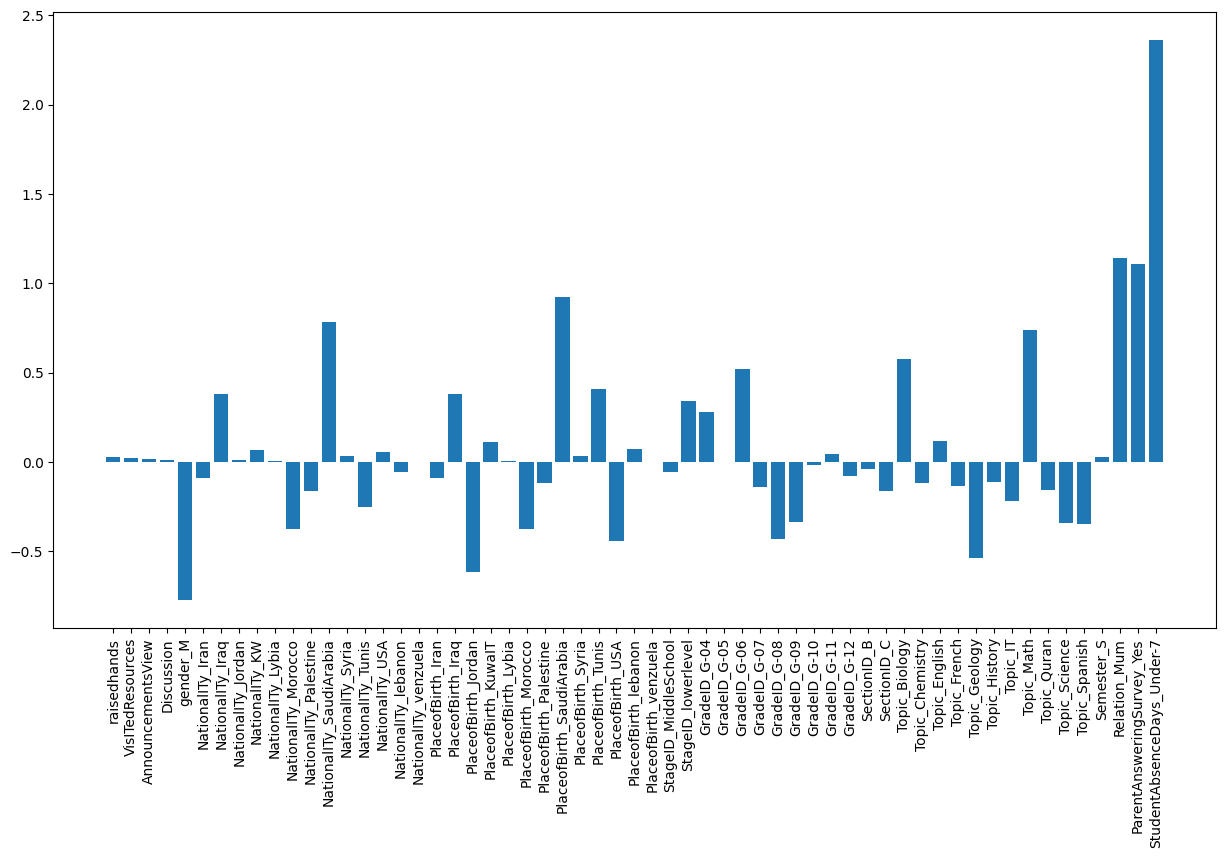

In [133]:
fig = plt.figure(figsize=(15,8))
plt.bar(X.columns, model_lr.coef_[2,:])
plt.xticks(rotation = 90)
plt.show()

### 문제 15. XGBoost 모델로 특징의 중요도 확인하기

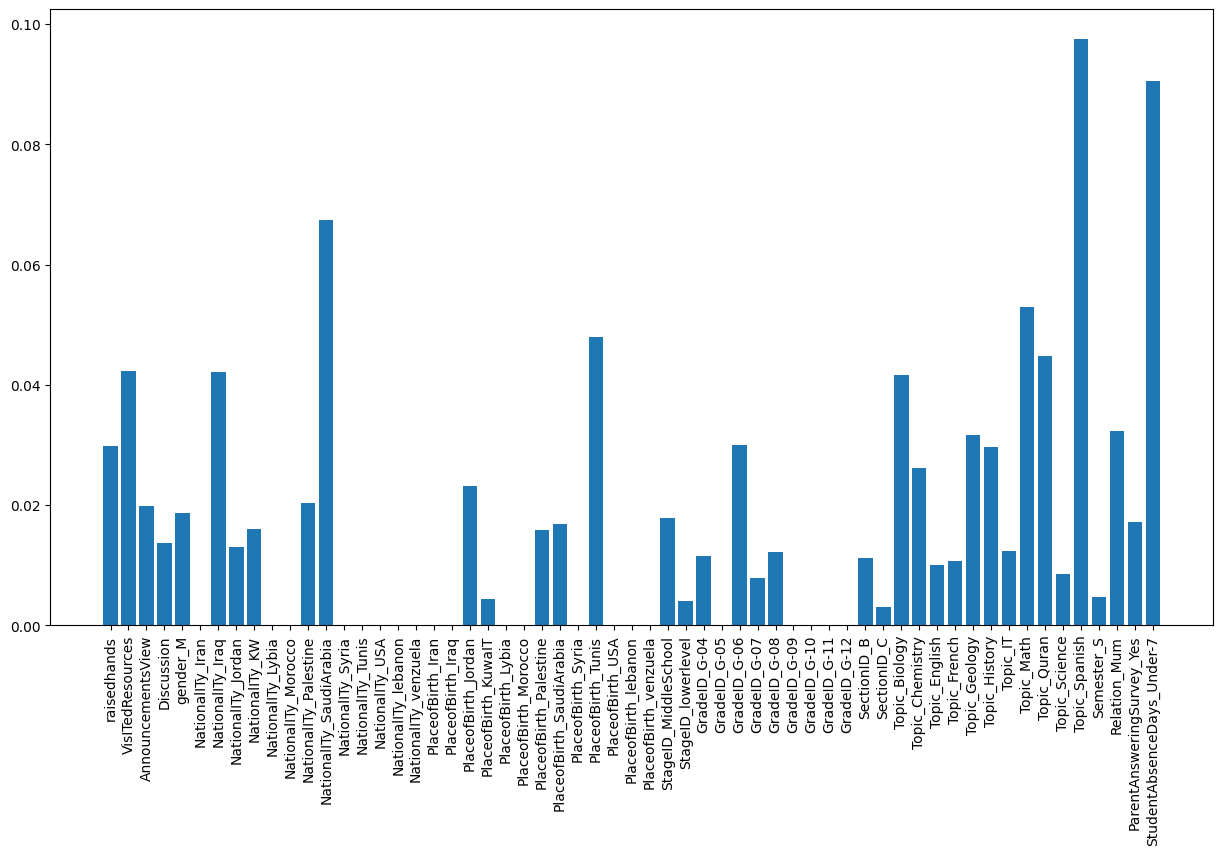

In [131]:
# XGBoost 모델의 feature_importances_ 속성을 plot하기

fig = plt.figure(figsize=(15,8))
plt.bar(X.columns, model_xgb.feature_importances_)
plt.xticks(rotation = 90)
plt.show()